In [ ]:
import pandas as pd
from datetime import datetime

data = pd.read_excel("data.xlsx")

data = data.drop_duplicates()

columns = []

for single_data in data :
    if single_data == "":
        single_data = pd.isna()
    if data[single_data][0] == pd.StringDtype:
        columns.append(single_data)

for col in columns:
    data[col] = data[col].str.strip()

numerical_vars = ["CustomerID", "Quantity", "UnitPrice"]

for col in numerical_vars:
    data[col] = data[col].astype(float)
    data[col] = data[col].fillna(0)

data["Description"] = data[col].fillna("No description")
data = data.drop(columns=["StockCode"])

print(data.head())
print(data.shape)
print(data.describe())
print(data.info())

  InvoiceNo  Description  Quantity         InvoiceDate  UnitPrice  CustomerID  \
0    536365         2.55       6.0 2010-12-01 08:26:00       2.55     17850.0   
1    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
2    536365         2.75       8.0 2010-12-01 08:26:00       2.75     17850.0   
3    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   
4    536365         3.39       6.0 2010-12-01 08:26:00       3.39     17850.0   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  
(536641, 7)
         Description       Quantity                 InvoiceDate  \
count  536641.000000  536641.000000                      536641   
mean        4.632656       9.620029  2011-07-04 08:57:06.087421   
min    -11062.060000  -80995.000000         2010-12-01 08:26:00   
25%         1.250000       1.000000         2011-03-28 10:52:00   
50%         2.080000       3.000000         20

In [9]:
data["Montant"] = data["Quantity"] * data["UnitPrice"]
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors='coerce')

rfm = []

for customer_id, client_df in data.groupby("CustomerID"):
    rfm.append({
        "CustomerID": customer_id,
        "Recence": (pd.Timestamp.now() - client_df["InvoiceDate"].max()).days,
        "Frequence": client_df["InvoiceNo"].nunique(),
        "Montant": client_df["Montant"].sum()
    })

rfm = pd.DataFrame(rfm)
print(rfm.head().sort_values(by="Recence"))


   CustomerID  Recence  Frequence     Montant
0         0.0     5407       3710  1447487.53
2     12347.0     5409          7     4310.00
4     12349.0     5426          1     1757.55
3     12348.0     5482          4     1797.24
1     12346.0     5732          2        0.00


In [16]:
import numpy as np
from sklearn.cluster import KMeans

encoded_data = pd.get_dummies(data=data, columns=["Country"], dtype=int)
featured_data = encoded_data.select_dtypes(include=[np.number])

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans.fit(featured_data)

print(kmeans.cluster_centers_)

[[ 8.07834238e+00  1.99686753e+00  8.07834238e+00  6.38465281e-10
   1.07191920e+01  1.82145965e-16 -7.68699340e-17  1.48107556e-05
  -5.44269491e-16 -1.78893358e-18 -4.14707331e-17 -1.53956708e-17
   1.04083409e-16  1.27597043e-17 -1.39211559e-16  5.25041285e-03
  -3.37728977e-17 -4.01154804e-17  4.88754934e-04  1.80411242e-16
   2.98697699e-17  2.10312729e-03  2.29308759e-17  3.48052756e-04
  -1.95373231e-16 -1.62630326e-16 -1.65340831e-18  7.00665654e-18
  -3.20381742e-17 -3.38271078e-17 -5.88071258e-16 -1.68051337e-17
   2.88809734e-04  5.12285526e-18 -2.23616698e-18 -3.41523684e-18
  -8.30065183e-16 -2.51643324e-16  8.66429201e-04 -1.06251813e-17
  -4.03865309e-18  9.89151122e-01  1.48848093e-03]
 [ 3.73563152e+00  1.29717618e+01  3.73563152e+00  1.39038420e+04
   2.15127394e+01  5.76933797e-03  1.86272506e-03  7.89683941e-05
   9.61091808e-03  1.48646389e-04  4.64519965e-05  3.51641614e-03
   2.83821699e-03  1.39355990e-04  1.80698266e-03  3.47228674e-02
   2.83357179e-04  3.2284

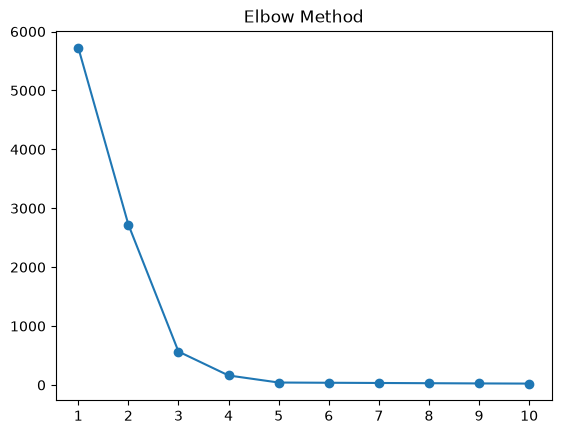

In [15]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

x , _ = make_blobs(n_samples=100, centers=5, cluster_std=0.5, random_state=42)
inertia = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    kmeans.fit(x)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

In [ ]:
kmeans_final = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans_final.fit(featured_data)

rfm["Cluster"] = kmeans_final.fit_predict(rfm)
print(rfm)

[[ 8.07834238e+00  1.99686753e+00  8.07834238e+00  6.40284270e-10
   1.07191920e+01  1.82145965e-16 -7.68699340e-17  1.48107556e-05
  -5.44269491e-16 -1.78893358e-18 -4.14707331e-17 -1.56125113e-17
   1.04083409e-16  1.27597043e-17 -1.39211559e-16  5.25041285e-03
  -3.37593451e-17 -4.03323208e-17  4.88754934e-04  1.80411242e-16
   2.98697699e-17  2.10312729e-03  2.29308759e-17  3.48052756e-04
  -1.95373231e-16 -1.62847166e-16 -1.65340831e-18  7.02020907e-18
  -3.20381742e-17 -3.46944695e-17 -5.87637577e-16 -1.68051337e-17
   2.88809734e-04  5.12285526e-18 -2.23955511e-18 -3.46944695e-18
  -8.29197822e-16 -2.51643324e-16  8.66429201e-04 -1.06251813e-17
  -4.03865309e-18  9.89151122e-01  1.48848093e-03]
 [ 3.73563152e+00  1.29717618e+01  3.73563152e+00  1.39038420e+04
   2.15127394e+01  5.76933797e-03  1.86272506e-03  7.89683941e-05
   9.61091808e-03  1.48646389e-04  4.64519965e-05  3.51641614e-03
   2.83821699e-03  1.39355990e-04  1.80698266e-03  3.47228674e-02
   2.83357179e-04  3.2284

19768.69424587037


46443347.71222663
6814.935635222583
0.9099031138535913
4500.712501541964


4500.696062322511
46443340.39630758
6814.935098466278
0.9099031280459688


1073.4309735672211
7705004.546776118
2775.788995362601
0.9850528234590269


Scores for each fold: [0.98503368 0.98547687 0.98582626 0.98558446 0.98600483]
Average R² Score: 0.9856


Dummy (Baseline) -> Score R² sur le test: -0.0000
Linear Regression -> Score R² sur le test: 0.9099
Ridge Regression -> Score R² sur le test: 0.9099
Random Forest Regressor -> Score R² sur le test: 0.9849
